In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm    # Used for plotting qq-plot
from statsmodels.stats.diagnostic import acorr_ljungbox     # Used in the Ljung-Box test


In [135]:
data = pd.read_csv('data/mitbih_train.csv', header=None)
data.columns = (list(range(187))) + ['label']

signal = data.drop(columns='label')
label = data['label']

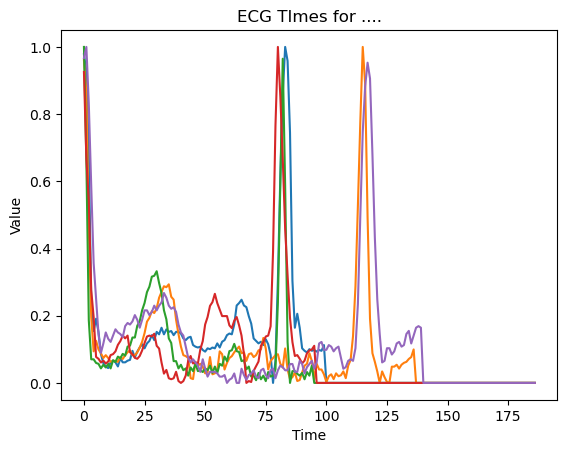

In [136]:
for i in range(5):
    plt.plot(signal.iloc[i])

plt.xlabel('Time')
plt.ylabel('Value')
plt.title('ECG TImes for ....')
plt.show()

In [137]:
print(data.head())
print(data.shape)
print(data.isna().any())

counts = label.value_counts().sort_index()
print(counts)

          0         1         2         3         4         5         6  \
0  0.977941  0.926471  0.681373  0.245098  0.154412  0.191176  0.151961   
1  0.960114  0.863248  0.461538  0.196581  0.094017  0.125356  0.099715   
2  1.000000  0.659459  0.186486  0.070270  0.070270  0.059459  0.056757   
3  0.925414  0.665746  0.541436  0.276243  0.196133  0.077348  0.071823   
4  0.967136  1.000000  0.830986  0.586854  0.356808  0.248826  0.145540   

          7         8         9  ...  178  179  180  181  182  183  184  185  \
0  0.085784  0.058824  0.049020  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.088319  0.074074  0.082621  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.043243  0.054054  0.045946  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.060773  0.066298  0.058011  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4  0.089202  0.117371  0.150235  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   186  label  
0  0.0    0.0  
1  0.0    0.0  
2  0.0    0.0  
3  0

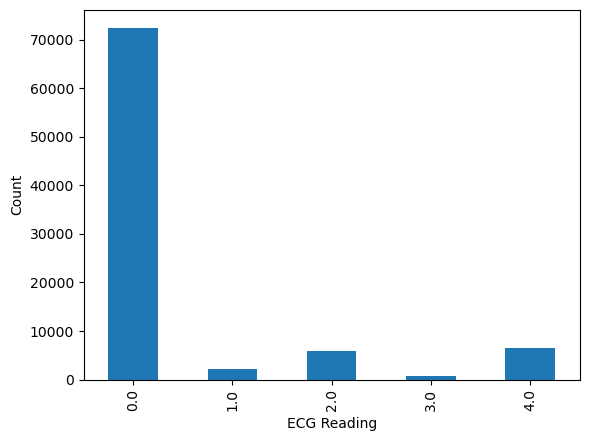

In [138]:
counts.plot(kind='bar')
plt.xlabel('ECG Reading')
plt.ylabel('Count')
plt.show()

There are 87,554 observations in the entire dataset, there are 72471 normal observatinos, as well as 2223 + 5788 + 641 + 6431 counts of abnormal observations. 

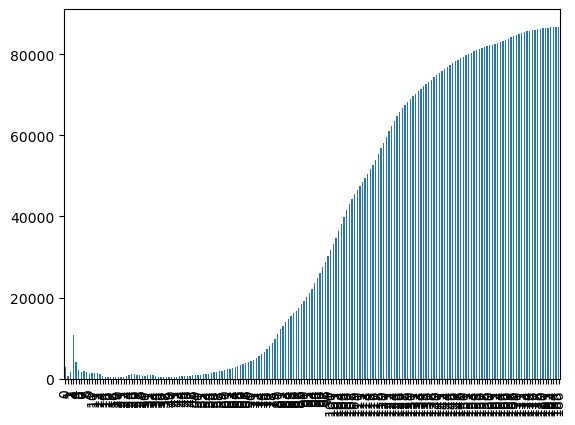

In [139]:
# There is a trail of zeros for a lot of the observations
signal_clean=signal.replace(0, None)
zero_counts = signal_clean.isna().sum()
zero_counts.plot(kind='bar')
plt.show()

In [140]:
data2 = data.copy()
signal_cols = data.columns.drop("label")

for idx, row in data2[signal_cols].iterrows():
    non_zero_pos = np.where(row.values != 0)[0]

    if len(non_zero_pos) > 0:
        last_nonzero = non_zero_pos[-1]

        data2.loc[idx, signal_cols[last_nonzero + 1:]] = np.nan

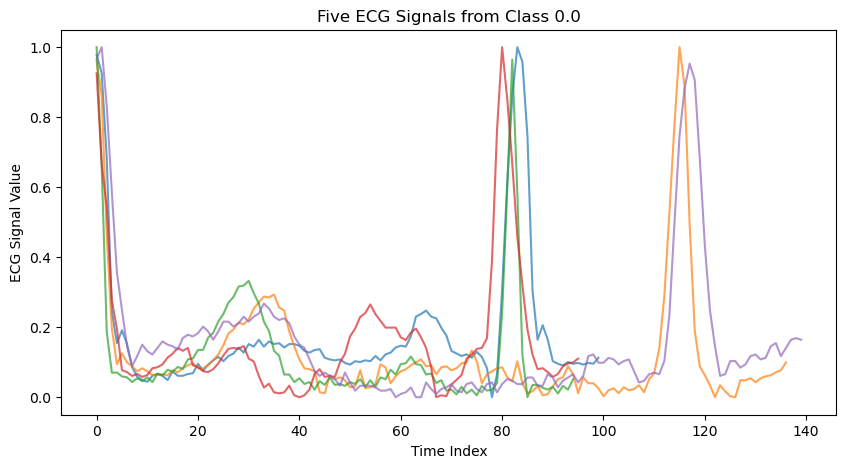

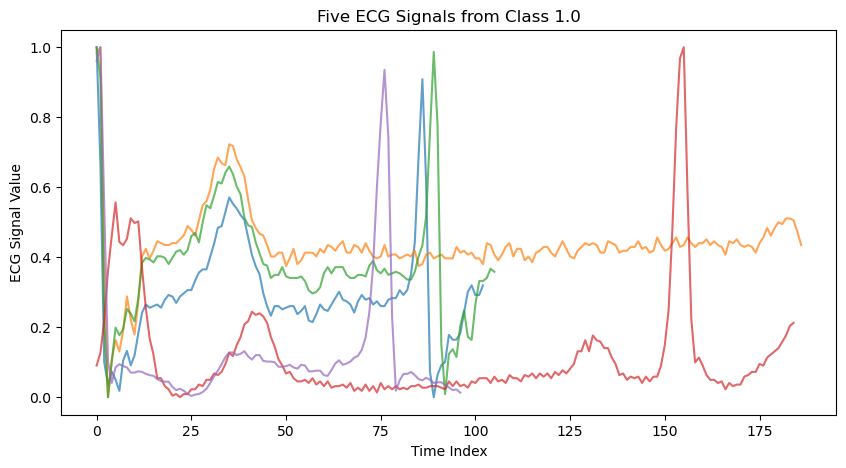

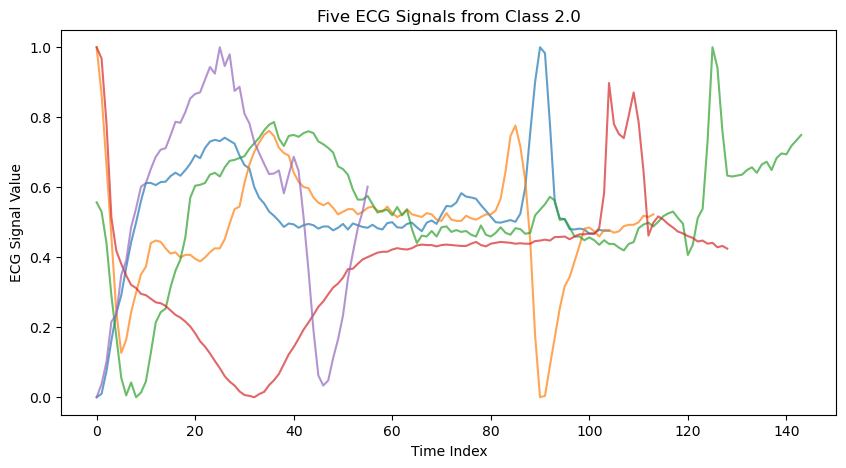

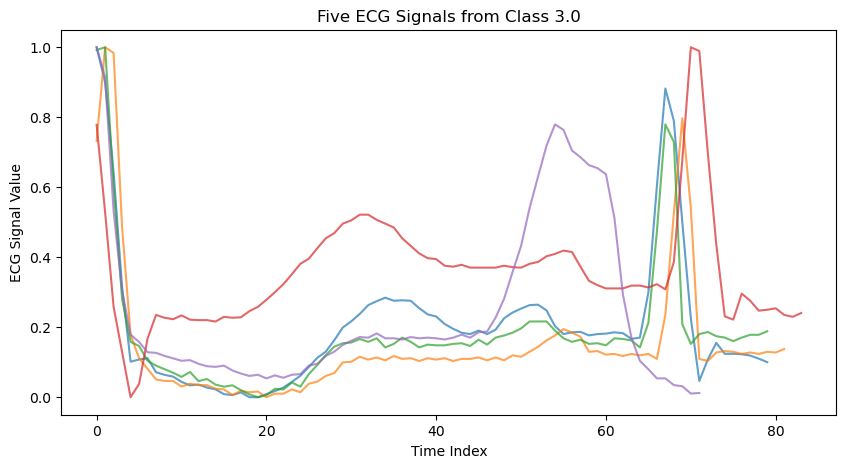

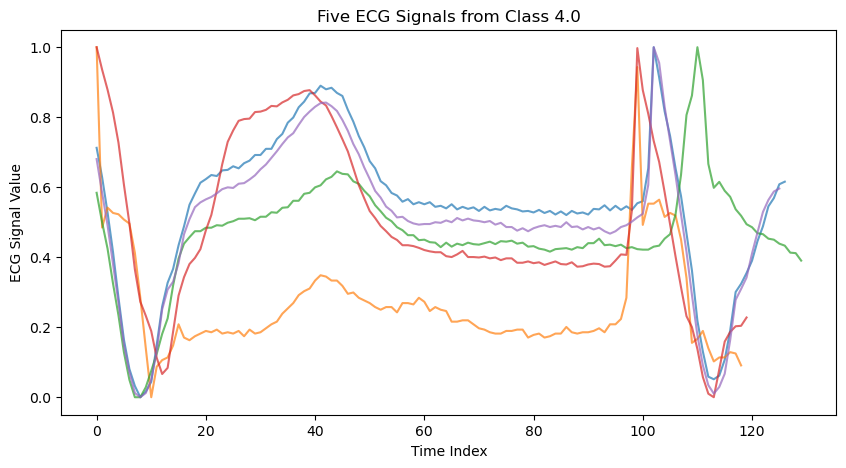

In [141]:
# plots of each type of ECG reading
for i in sorted(data2['label'].unique()):
    class_data = data2[data2['label'] == i]

    plt.figure(figsize=(10,5))

    for j in range(5):
        plt.plot(class_data.iloc[j, :187], alpha=0.7)

    plt.xlabel('Time Index')
    plt.ylabel('ECG Signal Value')
    plt.title(f'Five ECG Signals from Class {i}')
    plt.show()

binary_label
0    72471
1    15083
Name: count, dtype: int64


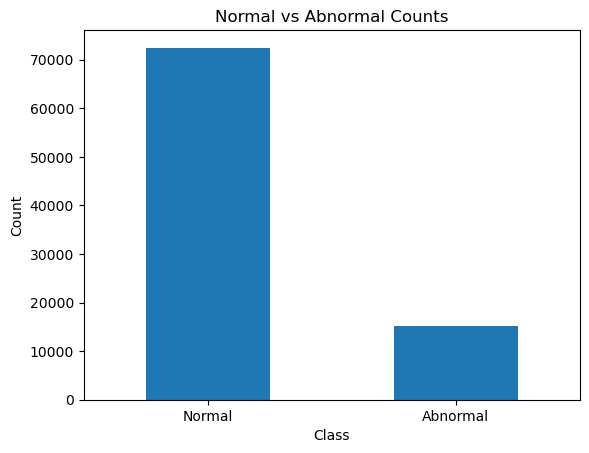

In [142]:
data2['binary_label'] = np.where(data2['label'] == 0, 0, 1)
binary_counts = data2['binary_label'].value_counts().sort_index()
print(binary_counts)

binary_counts.plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Normal vs Abnormal Counts')
plt.xticks([0, 1], ['Normal', 'Abnormal'], rotation=0)
plt.show()

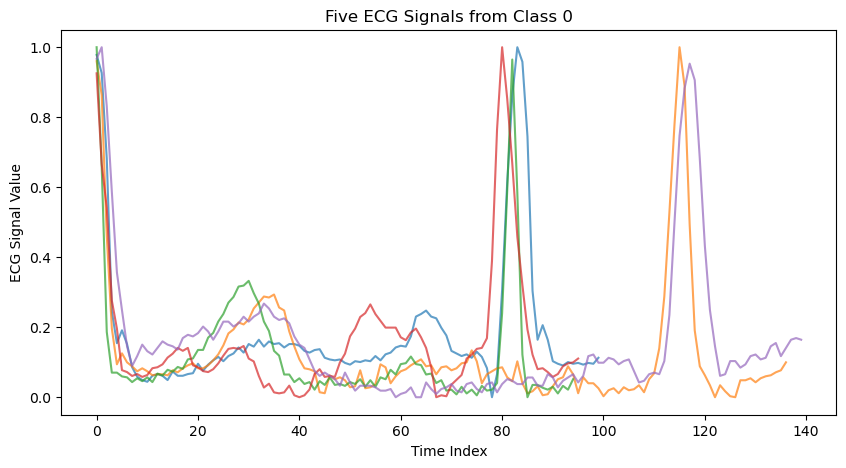

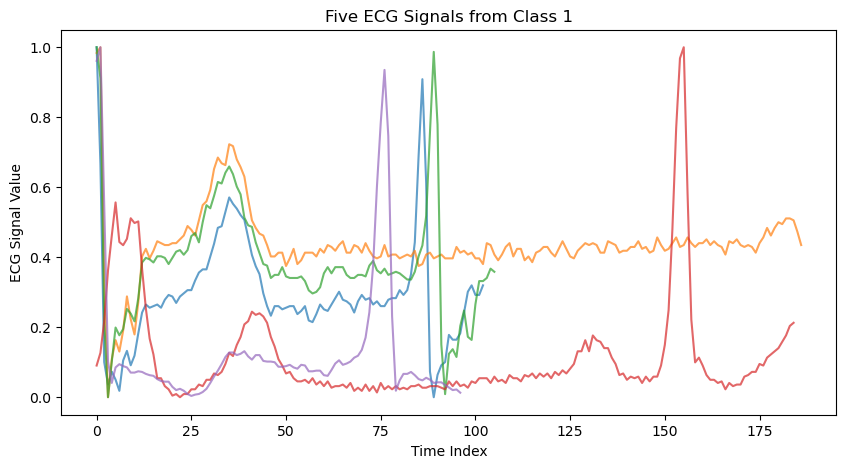

In [143]:
for i in data2['binary_label'].unique():
    subset = data2[data2['binary_label'] == i]

    plt.figure(figsize=(10,5))

    for j in range(5):
        plt.plot(subset.iloc[j, :187], alpha = 0.7)
    
    plt.xlabel('Time Index')
    plt.ylabel('ECG Signal Value')
    plt.title(f'Five ECG Signals from Class {i}')
    plt.show()

The PTB normal and abnormal datasets were explored, but the main analysis will use the MIT-BIH training dataset because it contains more observations and more detailed heartbeat class labels.

## ARIMA

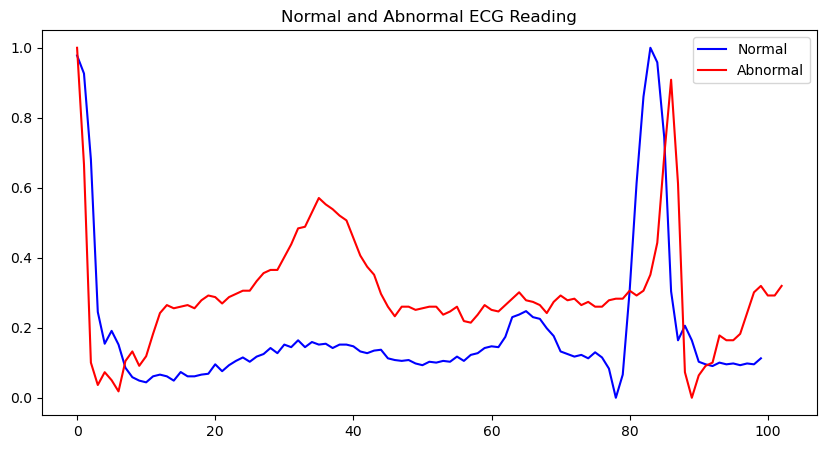

In [ ]:
normal = data2[data2['binary_label'] == 0].iloc[0, :187].dropna()
abnormal = data2[data2['binary_label'] == 1].iloc[0, :187].dropna()

normal = normal.reset_index(drop=True)  # Rests the index so we dont get weird time formats
abnormal = abnormal.reset_index(drop=True)

plt.figure(figsize=(10,5))
plt.plot(normal.iloc[:187], label='Normal', color='blue')
plt.plot(abnormal.iloc[:187], label='Abnormal', color='red')
plt.title('Normal and Abnormal ECG Reading')
plt.legend()
plt.show()

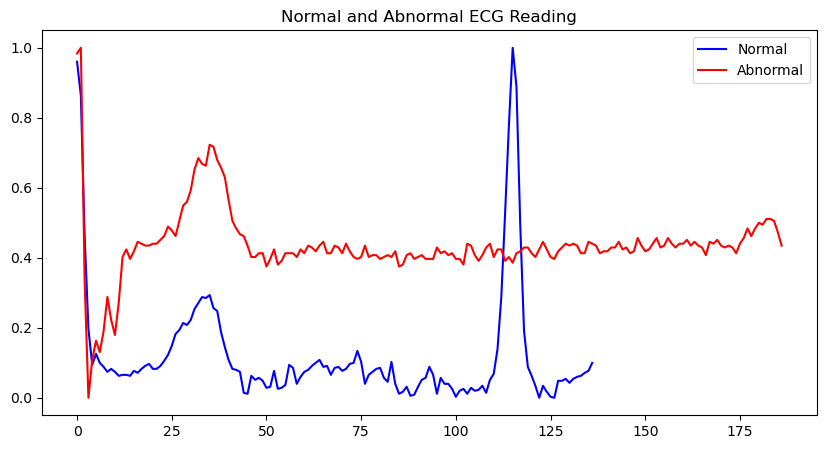

In [ ]:
normal_2 = data2[data2['binary_label'] == 0].iloc[1, :187].dropna()
abnormal_2 = data2[data2['binary_label'] == 1].iloc[1, :187].dropna()

plt.figure(figsize=(10,5))
plt.plot(normal_2.iloc[:187], label='Normal', color='blue')
plt.plot(abnormal_2.iloc[:187], label='Abnormal', color='red')
plt.title('Normal and Abnormal ECG Reading')
plt.legend()
plt.show()

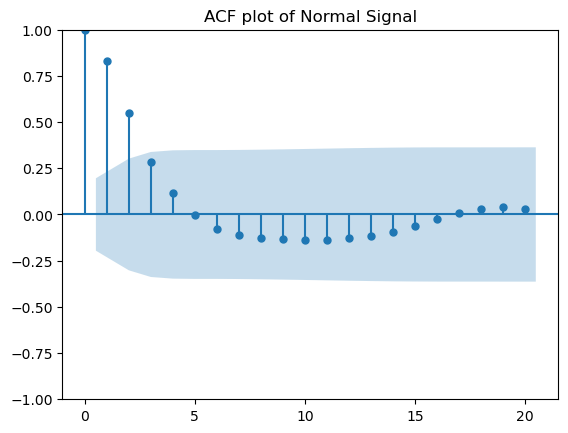

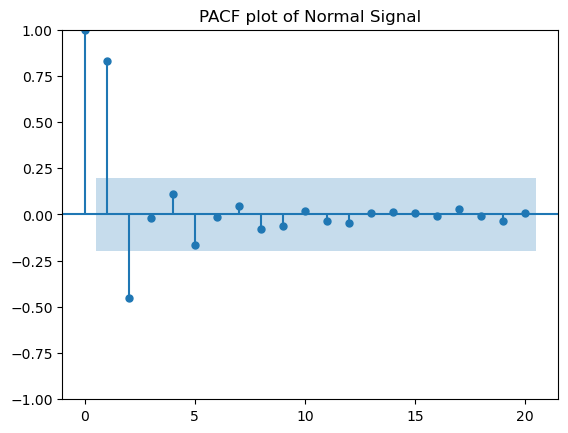

In [ ]:
plot_acf(normal)
plt.title('ACF plot of Normal Signal')
plot_pacf(normal)
plt.title('PACF plot of Normal Signal')
plt.show()

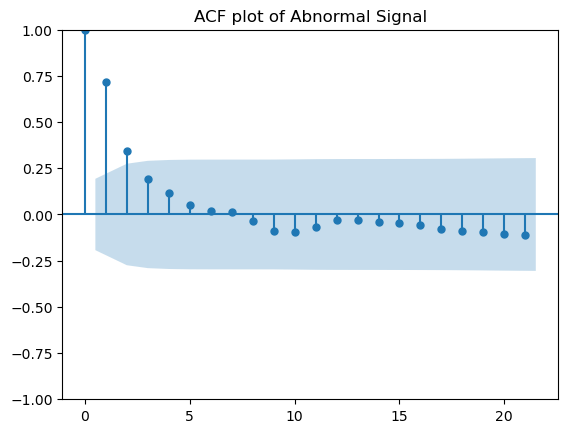

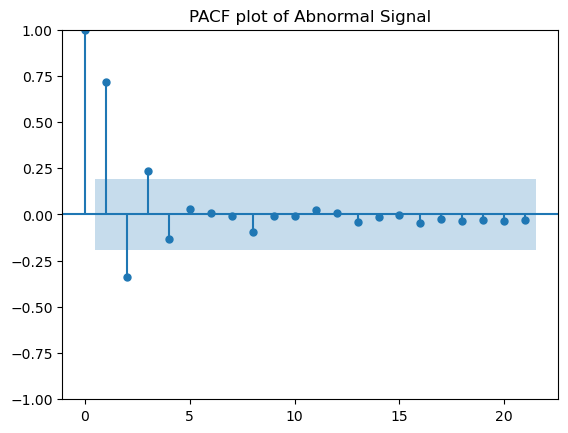

In [ ]:
plot_acf(abnormal)
plt.title('ACF plot of Abnormal Signal')
plot_pacf(abnormal)
plt.title('PACF plot of Abnormal Signal')
plt.show()

Text(0.5, 1.0, 'pacf plot normal 2')

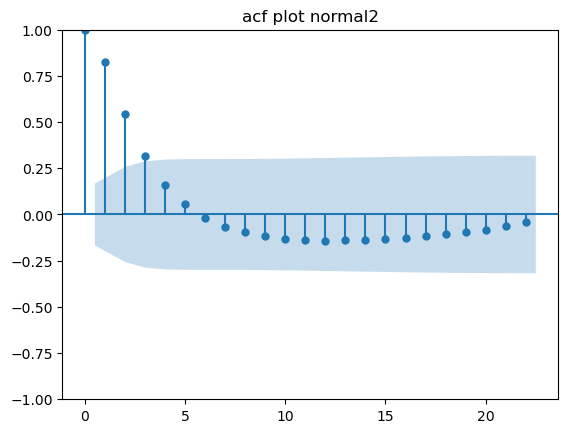

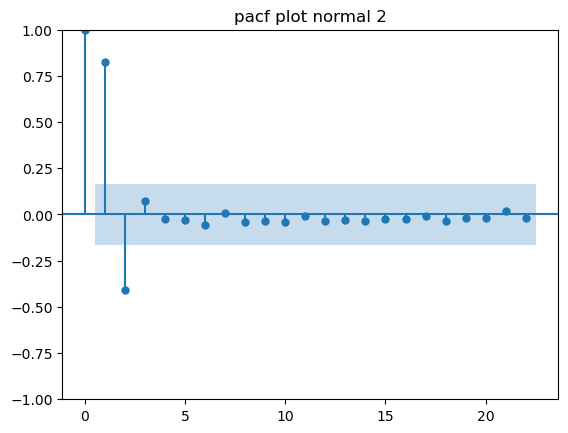

In [ ]:
plot_acf(normal_2)
plt.title('acf plot normal2')
plot_pacf(normal_2)
plt.title('pacf plot normal 2')


Text(0.5, 1.0, 'pacf plot abnormal 2')

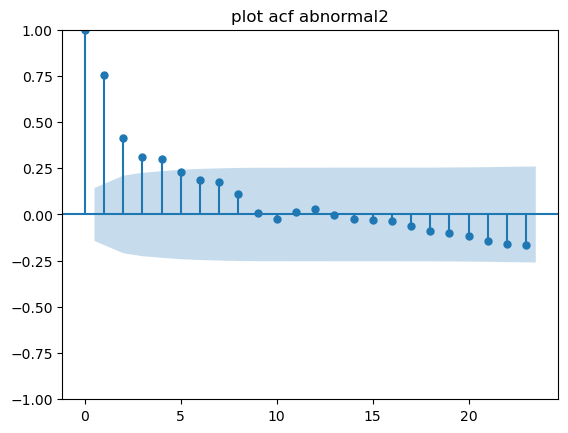

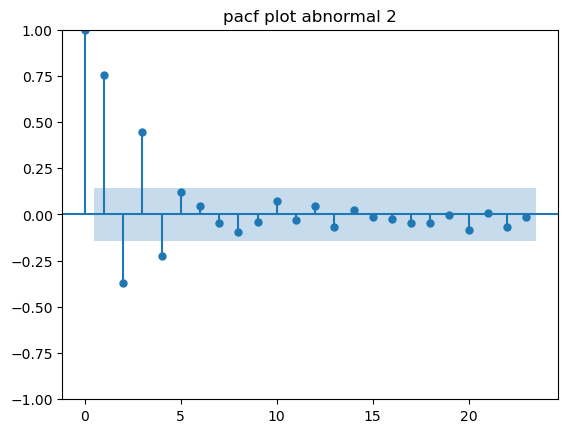

In [ ]:
plot_acf(abnormal_2)
plt.title('plot acf abnormal2')
plot_pacf(abnormal_2)
plt.title('pacf plot abnormal 2')

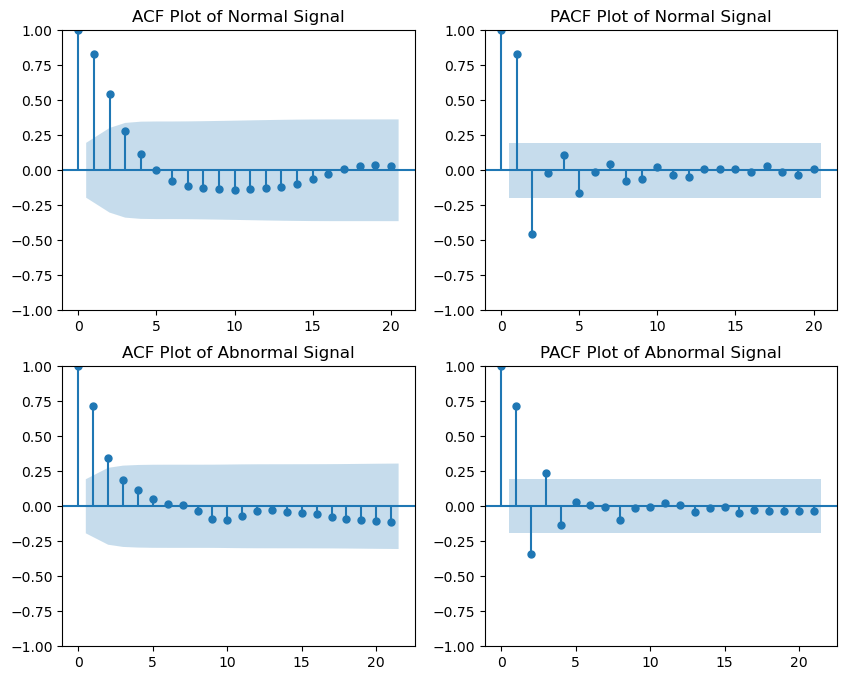

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

plot_acf(normal, ax=axs[0,0], title='ACF Plot of Normal Signal')

plot_pacf(normal, ax=axs[0,1], title='PACF Plot of Normal Signal')

plot_acf(abnormal, ax=axs[1,0], title='ACF Plot of Abnormal Signal')

plot_pacf(abnormal, ax=axs[1,1], title='PACF Plot of Abnormal Signal')
plt.show()

Since the ACF plot decays while PACF plot cuts off, this suggests an AR model

In [ ]:
# Check if data is stationary and if we need to apply a differencing:
stationary = adfuller(normal)
print(f'ADF Statistic: {stationary[0]}')
print(f'p-value: {stationary[1]}')

ADF Statistic: -4.137487190665371
p-value: 0.0008391988892750893


Since our p-value is small, this suggests our data is stationary and we do not need a difference factor

In [ ]:
# Normal AR Model:

# ARIMA(1,0,0)
model_norm_100 = ARIMA(normal, order=(1,0,0))
norm_fit_100 = model_norm_100.fit()
norm_100_aic = norm_fit_100.aic
norm_100_bic = norm_fit_100.bic

# ARIMA(2,0,0)
model_norm_200 = ARIMA(normal, order=(2,0,0))
norm_fit_200 = model_norm_200.fit()
norm_200_aic = norm_fit_200.aic
norm_200_bic = norm_fit_200.bic


model_norm_300 = ARIMA(normal, order=(3,0,0))
norm_fit_300 = model_norm_300.fit()
norm_300_aic = norm_fit_300.aic
norm_300_bic = norm_fit_300.bic

model_norm_400 = ARIMA(normal, order=(4,0,0))
norm_fit_400 = model_norm_400.fit()
norm_400_aic = norm_fit_400.aic
norm_400_bic = norm_fit_400.bic

In [ ]:
# Abnormal AR Model:

# ARIMA(1,0,0)
model_ab_100 = ARIMA(abnormal, order=(1,0,0))
ab_fit_100 = model_ab_100.fit()
ab_100_aic = ab_fit_100.aic
ab_100_bic = ab_fit_100.bic

# ARIMA(2,0,0)
model_ab_200 = ARIMA(abnormal, order=(2,0,0))
ab_fit_200 = model_ab_200.fit()
ab_200_aic = ab_fit_200.aic
ab_200_bic = ab_fit_200.bic

model_ab_300 = ARIMA(abnormal, order=(3,0,0))
ab_fit_300 = model_ab_300.fit()
ab_300_aic = ab_fit_300.aic
ab_300_bic = ab_fit_300.bic

model_ab_400 = ARIMA(abnormal, order=(4,0,0))
ab_fit_400 = model_ab_400.fit()
ab_400_aic = ab_fit_400.aic
ab_400_bic = ab_fit_400.bic

In [ ]:
ar_table = {'signal': ['Normal', 'Normal', 'Normal', 'Normal', 'Abnormal', 'Abnormal', 'Abnormal', 'Abnormal'],
         'Model': ['ARIMA(1,0,0)', 'ARIMA(2,0,0)', 'ARIMA(3,0,0)', 'ARIMA(4,0,0)', 'ARIMA(1,0,0)', 'ARIMA(2,0,0)', 'ARIMA(3,0,0)', 'ARIMA(4,0,0)'], 
         'AIC': [norm_100_aic, norm_200_aic, norm_300_aic, norm_400_aic, ab_100_aic, ab_200_aic, ab_300_aic, ab_400_aic],
         'BIC': [norm_100_bic, norm_200_bic, norm_300_bic, norm_400_bic, ab_100_bic, ab_200_bic, ab_300_bic, ab_400_bic]}

ar_df = pd.DataFrame(ar_table)
ar_df

,signal,Model,AIC,BIC
0,Normal,"ARIMA(1,0,0)",-191.104343,-183.288832
1,Normal,"ARIMA(2,0,0)",-261.209762,-250.789081
2,Normal,"ARIMA(3,0,0)",-266.167037,-253.141186
3,Normal,"ARIMA(4,0,0)",-265.090729,-249.459708
4,Abnormal,"ARIMA(1,0,0)",-179.695124,-171.790937
5,Abnormal,"ARIMA(2,0,0)",-221.731205,-211.192289
6,Abnormal,"ARIMA(3,0,0)",-234.205735,-221.032090
7,Abnormal,"ARIMA(4,0,0)",-243.283491,-227.475117


In [ ]:
# ARIMA Normal:
model_norm_101 = ARIMA(normal, order=(1,0,1))
norm_101_fit = model_norm_101.fit()
norm_101_aic = norm_101_fit.aic
norm_101_bic = norm_101_fit.bic

model_norm_202 = ARIMA(normal, order=(2,0,2))
norm_202_fit = model_norm_202.fit()
norm_202_aic = norm_202_fit.aic
norm_202_bic = norm_202_fit.bic

model_norm_201 = ARIMA(normal, order=(2,0,1))
norm_201_fit = model_norm_201.fit()
norm_201_aic = norm_201_fit.aic
norm_201_bic = norm_201_fit.bic

model_norm_102 = ARIMA(normal, order=(1,0,2))
norm_102_fit = model_norm_102.fit()
norm_102_aic = norm_102_fit.aic
norm_102_bic = norm_102_fit.bic

model_norm_212 = ARIMA(normal, order=(2,1,2))
norm_212_fit = model_norm_212.fit()
norm_212_aic = norm_212_fit.aic
norm_212_bic = norm_212_fit.bic

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# ARIMA Abnormal
model_ab_101 = ARIMA(abnormal, order=(1,0,1))
ab_101_fit = model_ab_101.fit()
ab_101_aic = ab_101_fit.aic
ab_101_bic = ab_101_fit.bic

model_ab_202 = ARIMA(abnormal, order=(2,0,2))
ab_202_fit = model_ab_202.fit()
ab_202_aic = ab_202_fit.aic
ab_202_bic = ab_202_fit.bic

model_ab_201 = ARIMA(abnormal, order=(2,0,1))
ab_201_fit = model_ab_201.fit()
ab_201_aic = ab_201_fit.aic
ab_201_bic = ab_201_fit.bic

model_ab_102 = ARIMA(abnormal, order=(1,0,2))
ab_102_fit = model_ab_102.fit()
ab_102_aic = ab_102_fit.aic
ab_102_bic = ab_102_fit.bic

model_ab_212 = ARIMA(abnormal, order=(2,1,2))
ab_212_fit = model_ab_212.fit()
ab_212_aic = ab_212_fit.aic
ab_212_bic = ab_212_fit.bic

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
arima_table = {'signal': ['Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Abnormal', 'Abnormal', 'Abnormal', 'Abnormal', 'Abnormal'],
         'Model': ['ARIMA(1,0,1)', 'ARIMA(2,0,2)', 'ARIMA(2,0,1)', 'ARIMA(1,0,2)', 'ARIMA(2,1,2)', 'ARIMA(1,0,1)', 'ARIMA(2,0,2)', 'ARIMA(2,0,1)', 'ARIMA(1,0,2)', 'ARIMA(2,1,2)'], 
         'AIC': [norm_101_aic, norm_202_aic, norm_201_aic, norm_102_aic, norm_212_aic, ab_101_aic, ab_202_aic, ab_201_aic, ab_102_aic, ab_212_aic],
         'BIC': [norm_101_bic, norm_202_bic, norm_201_bic, norm_102_bic, norm_212_bic, ab_101_bic, ab_202_bic, ab_201_bic, ab_102_bic, ab_212_bic]}

arima_df = pd.DataFrame(arima_table)
arima_df

,signal,Model,AIC,BIC
0,Normal,"ARIMA(1,0,1)",-246.423046,-236.002365
1,Normal,"ARIMA(2,0,2)",-265.064928,-249.433907
2,Normal,"ARIMA(2,0,1)",-266.739254,-253.713403
3,Normal,"ARIMA(1,0,2)",-264.301846,-251.275995
4,Normal,"ARIMA(2,1,2)",-262.471396,-249.495797
5,Abnormal,"ARIMA(1,0,1)",-234.041034,-223.502118
6,Abnormal,"ARIMA(2,0,2)",-246.771526,-230.963152
7,Abnormal,"ARIMA(2,0,1)",-240.059116,-226.885471
8,Abnormal,"ARIMA(1,0,2)",-248.564096,-235.390451
9,Abnormal,"ARIMA(2,1,2)",-235.822719,-222.697855


In [ ]:
model_scores = pd.concat([ar_df, arima_df])
model_scores = model_scores.sort_values(by=['AIC', 'BIC'], ascending=False)
model_scores

,signal,Model,AIC,BIC
4,Abnormal,"ARIMA(1,0,0)",-179.695124,-171.790937
0,Normal,"ARIMA(1,0,0)",-191.104343,-183.288832
5,Abnormal,"ARIMA(2,0,0)",-221.731205,-211.192289
5,Abnormal,"ARIMA(1,0,1)",-234.041034,-223.502118
6,Abnormal,"ARIMA(3,0,0)",-234.205735,-221.032090
9,Abnormal,"ARIMA(2,1,2)",-235.822719,-222.697855
7,Abnormal,"ARIMA(2,0,1)",-240.059116,-226.885471
7,Abnormal,"ARIMA(4,0,0)",-243.283491,-227.475117
0,Normal,"ARIMA(1,0,1)",-246.423046,-236.002365
6,Abnormal,"ARIMA(2,0,2)",-246.771526,-230.963152


For the selected normal heartbeat signal, ARIMA(2,0,1) produced the lowest AIC/BIC among the candidate models considered. This result should be interpreted as a model for this selected signal, not as a universal model for all normal ECG signals.

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


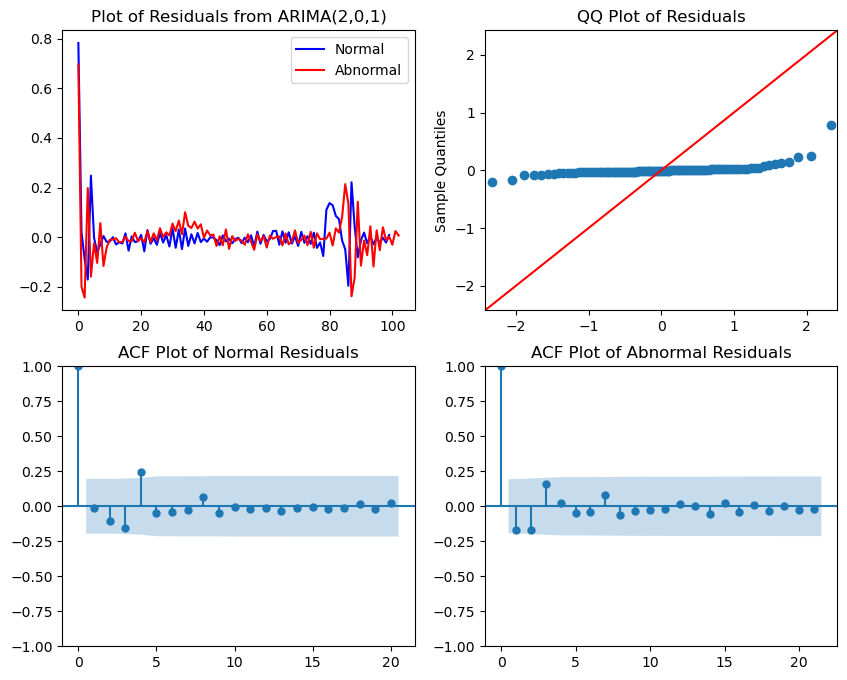

In [ ]:
# ARIMA(2,0,1)
resid_norm_201 = norm_201_fit.resid
resid_ab_201 = ab_201_fit.resid

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].plot(resid_norm_201, color='blue', label='Normal')
axs[0,0].plot(resid_ab_201, color='red', label='Abnormal')
axs[0,0].set_title('Plot of Residuals from ARIMA(2,0,1)')
axs[0,0].legend()

sm.qqplot(resid_norm_201, line='45', ax=axs[0,1], color='blue')
axs[0,1].set_title('QQ Plot of Residuals')
axs[0,1].set_xlabel('')

plot_acf(resid_norm_201, ax=axs[1, 0], title='ACF Plot of Normal Residuals')
plot_acf(resid_ab_201, ax=axs[1,1], title='ACF Plot of Abnormal Residuals')
plt.show()


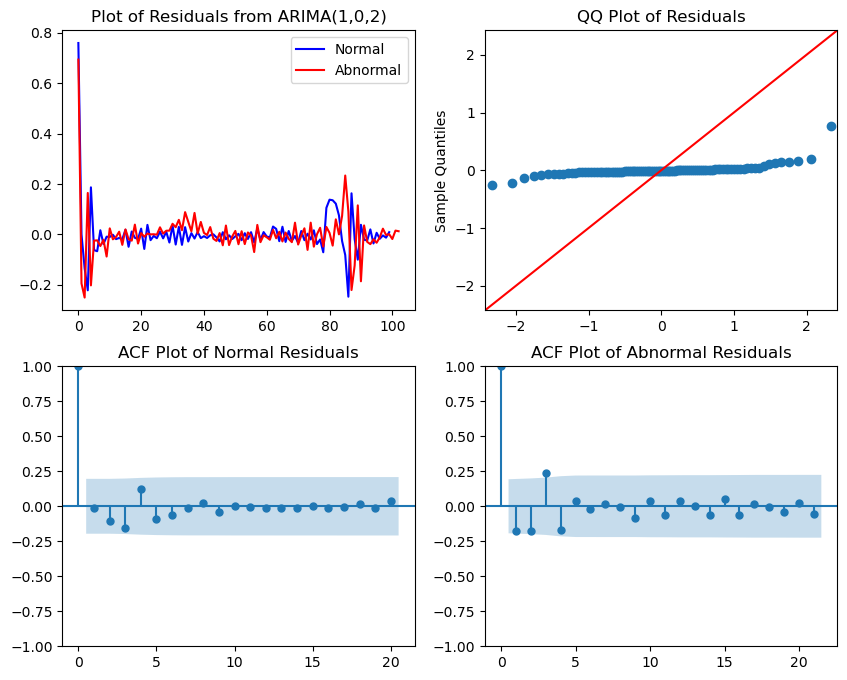

In [ ]:
# ARIMA(1,0,2)
resid_norm_102 = norm_102_fit.resid
resid_ab_102 = ab_102_fit.resid

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].plot(resid_norm_102, color='blue', label='Normal')
axs[0,0].plot(resid_ab_102, color='red', label='Abnormal')
axs[0,0].set_title('Plot of Residuals from ARIMA(1,0,2)')
axs[0,0].legend()

sm.qqplot(resid_norm_102, line='45', ax=axs[0,1], color='blue')
axs[0,1].set_title('QQ Plot of Residuals')
axs[0,1].set_xlabel('')

plot_acf(resid_norm_102, ax=axs[1, 0], title='ACF Plot of Normal Residuals')
plot_acf(resid_ab_102, ax=axs[1,1], title='ACF Plot of Abnormal Residuals')
plt.show()


In [ ]:
# Ljung-Box Test
norm_lb_test = acorr_ljungbox(resid_norm_201, lags=[5,10,15,20], return_df=True)
ab_lb_test = acorr_ljungbox(resid_ab_102, lags=[5,10,15,20], return_df=True)

norm_lb_test['Signal'] = 'Normal'
ab_lb_test['Signal'] = 'Abnormal'

norm_ab_lb = pd.concat([norm_lb_test, ab_lb_test])
norm_ab_lb

,lb_stat,lb_pvalue,Signal
5,10.363291,0.065572,Normal
10,11.344707,0.331300,Normal
15,11.525831,0.714507,Normal
20,11.762605,0.924005,Normal
5,15.916120,0.007088,Abnormal
10,17.015338,0.074025,Abnormal
15,18.406934,0.241876,Abnormal
20,19.174684,0.510499,Abnormal


The Ljung-Box results mostly show large p-values at higher lags, suggesting that the selected ARIMA models removed much of the autocorrelation from the residuals. However, a few early lags have p-values below 0.05, which suggests that some short-lag autocorrelation may remain. Therefore, the ARIMA models are reasonable but not perfect.

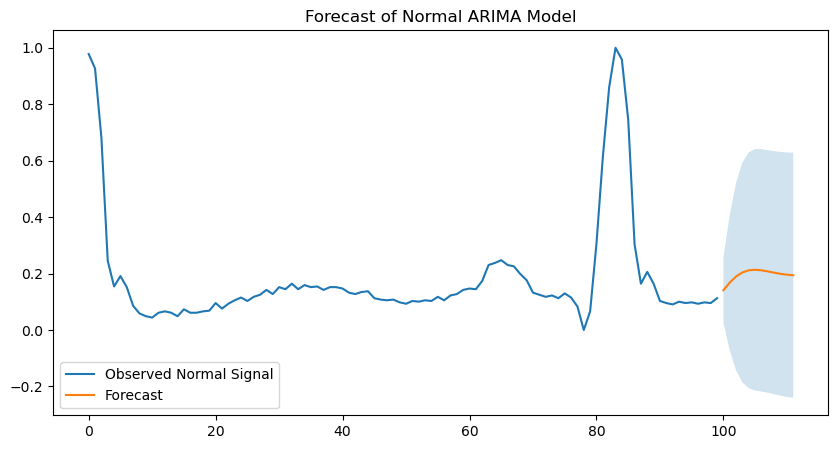

In [ ]:
# Normal Forecasting:
forecast_steps = 12
forecast_norm = norm_201_fit.get_forecast(steps=forecast_steps)
forecast_norm_val = forecast_norm.predicted_mean
forecast_norm_ci = forecast_norm.conf_int()
forecast_index_norm = range(len(normal), len(normal) + forecast_steps)

plt.figure(figsize=(10,5))
plt.plot(range(len(normal)), normal, label='Observed Normal Signal')
plt.plot(forecast_index_norm, forecast_norm_val, label='Forecast')
plt.fill_between(       # Confidence interval 
    forecast_index_norm,
    forecast_norm_ci.iloc[:, 0],
    forecast_norm_ci.iloc[:, 1],
    alpha=0.2
)
plt.legend()
plt.title('Forecast of Normal ARIMA Model')
plt.show()

The forecast quickly stabilizes toward the model’s long run mean, which is expected for a stationary ARMA type model.

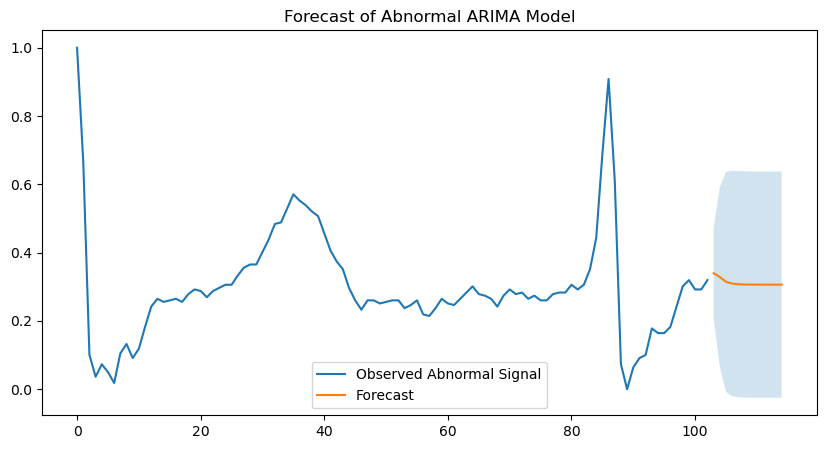

In [ ]:
# Abnormal Forecasting:
forecast_ab = ab_102_fit.get_forecast(steps=forecast_steps)
forecast_ab_val = forecast_ab.predicted_mean
forecast_ab_ci = forecast_ab.conf_int()
forecast_index_ab = range(len(abnormal), len(abnormal) + forecast_steps)

plt.figure(figsize=(10,5))
plt.plot(range(len(abnormal)), abnormal, label='Observed Abnormal Signal')
plt.plot(forecast_index_ab, forecast_ab_val, label='Forecast')
plt.fill_between(
    forecast_index_ab,
    forecast_ab_ci.iloc[:, 0],
    forecast_ab_ci.iloc[:, 1],
    alpha=0.2
)
plt.legend()
plt.title('Forecast of Abnormal ARIMA Model')
plt.show()

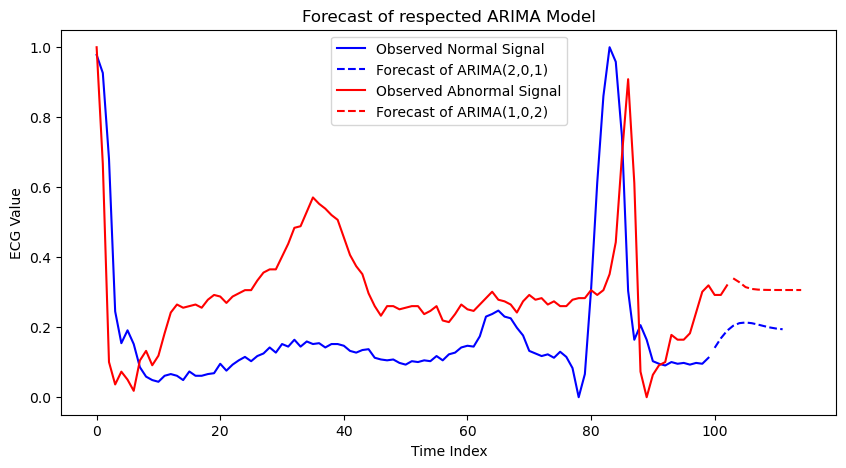

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(range(len(normal)), normal, label='Observed Normal Signal', 
         color='blue')
plt.plot(forecast_index_norm, forecast_norm_val, label='Forecast of ARIMA(2,0,1)', 
         color='blue', linestyle='dashed')

plt.plot(range(len(abnormal)), abnormal, label='Observed Abnormal Signal', 
         color='red')
plt.plot(forecast_index_ab, forecast_ab_val, label='Forecast of ARIMA(1,0,2)', 
         color='red', linestyle='dashed')

plt.title('Forecast of respected ARIMA Model')
plt.xlabel('Time Index')
plt.ylabel('ECG Value')
plt.legend()
plt.show()